In [118]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
#plt.rcParams['font.family'] = 'Helvetica'   # cambia la tipografía global a Helvetica
#matplotlib.style.use("ggplot")

import pandas as pd
import seaborn as sns
import os

In [119]:
%matplotlib inline

In [120]:
from pyunicorn.timeseries import RecurrencePlot
import logging
logging.basicConfig(level=logging.CRITICAL)

In [ ]:
FILE_NAME = r"E:\Pruebas%20BCI\SeñalesProcesadas10Hz2\AndreaBosch\S1\10deTorquePre.csv"
#FILE_NAME = r"E:\Pruebas%20BCI\SeñalesProcesadas10Hz2\AndreaBosch\S1\pasivoPre.csv"


selected_channels = [
    ["C2", "C1", "FCz", "Cz", "C3", "CP3"],
    ["C2", "C1", "FCz", "Cz", "C3", "CP3"],
    ["C2", "C1", "FCz", "Cz", "C3", "CP3"]
]


# selected_channels = [
#     ["C2", "C1", "FCz", "Cz", "C3", "CP3"],
#     ["FC4", "C1", "Cz", "C1", "P3"],
#     ["C3", "C2", "CP3"]
# ]

#INPUT

# selected_channels = [["C4", "C1", "FCz", "Cz", "Pz"],
#                      ["Cz", "Oz", "C3", "FCz", "P3"],
#                      ["C3", "FC4", "CP3", "P4"]]

#INPUT

#selected_channels = [["C3", "CP3", "C1", "Pz", "Oz", "C4", "CP4"],
#                       ["Oz", "C3", "P3", "FC4"],
#                      ["CP3", "P3", "C3", "C4", "C2", "P4"]]

#OUTPUT
#selected_channels = [["Cz", "C1", "C2", "P3"],
#                    ["FCz", "Oz", "P3", "CP4"],
#                    ["C1", "C2", "P4", "O2"]]

#BETE
#selected_channels = [["FC4", "Pz", "FCz", "C2"],
#                    ["Cz", "O2"],
#                    ["C2", "FC4", "CP3"]]

band = "mu"

if band == "mu":
    selected_channels = selected_channels[0]
elif band == "beta":
    selected_channels = selected_channels[1]
else:
    selected_channels = selected_channels[2]


In [177]:
%matplotlib inline

In [178]:
data = pd.read_csv(FILE_NAME)
binary_signal = data["Binaria"]
selected_columns = [f"{band}_" + ch for ch in selected_channels]
data = data[selected_columns]
data.shape

(2606, 6)

In [179]:
data.std().mean()

np.float64(0.04443523386153636)

In [180]:
data

,mu_C2,mu_C1,mu_FCz,mu_Cz,mu_C3,mu_CP3
0,0.060045,0.078305,0.041697,0.022662,0.049447,0.022822
1,0.050178,0.089769,0.043771,0.021880,0.039001,0.018369
2,0.033015,0.089838,0.047580,0.020560,0.033007,0.013488
3,0.014368,0.070380,0.062818,0.025963,0.044322,0.012018
4,0.009859,0.052260,0.070042,0.043147,0.075741,0.014975
...,...,...,...,...,...,...
2601,0.121066,0.132065,0.150749,0.110596,0.237847,0.113736
2602,0.122638,0.115141,0.124615,0.096282,0.196666,0.087254
2603,0.105928,0.162913,0.135475,0.076275,0.233983,0.068095
2604,0.094265,0.210695,0.177675,0.070227,0.305534,0.070803


In [181]:
50 * (1 - 0.95)

2.500000000000002

In [182]:
thresh = data.std().max()
thresh

np.float64(0.05745496339858415)

In [183]:
from statistics import mode

In [184]:
win_len = 80
overlapp = 0.90

step = int(win_len * (1 - overlapp))

recurrence_plots = []
binary_signal_2 = []

binary_signal = binary_signal > 0.5

for i in range(0, len(binary_signal) - win_len + 1, step):
    window_data = data.values[i:i + win_len, :]
    
    binary_signal_2.append(mode(binary_signal[i:i + win_len]))
    
    rp = RecurrencePlot(
        window_data,
        threshold=0.08, 
        #tau=3,
        #adaptive_neighborhood_size=10,
        epsilon='distance',
        metric="supremum",
        dim=3  # Dimensión del espacio de fase
    )
    recurrence_plots.append(rp)

binary_signal_with_transition = binary_signal_2.copy()

# === Marcar transiciones en ventanas ===
binary_signal_2 = np.array(binary_signal_2, dtype=int)
binary_signal_with_transition = binary_signal_2.copy()

# Detectar cambios entre ventanas
changes = np.where(np.diff(binary_signal_2) != 0)[0]

for idx in changes:
    # Rango de 4 antes y 4 después del cambio (en ventanas)
    start = max(0, idx - 3)
    end   = min(len(binary_signal_with_transition), idx + 5)
    
    binary_signal_with_transition[start:end] = -1
binary_signal_2 = binary_signal_with_transition

Calculating recurrence plot at fixed threshold...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed threshold...
Calculatin

In [185]:
plt.plot(binary_signal_2)

TypeError: Axes3D.plot() missing 1 required positional argument: 'ys'

In [ ]:
for i in range(0, len(recurrence_plots), 50):
    plt.figure(figsize= (4, 4))
    plt.imshow(recurrence_plots[i].recurrence_matrix(), cmap='binary', origin='lower')
    plt.title("Activity")


In [187]:

dict_ = {
    "recurrence_rate": [],
    "determinism": [],
    "laminarity": [],
    "trapping_time": [],
    "diag_entropy": [],
    "vert_entropy": [],
    "avg_diag_length": [],
    "average_vertlength": [],
    "average_white_vertlength": [],
    "max_diaglength": [],
    "max_vertlength": [],
    "max_white_vertlength": [],
    "mean_recurrence_time": [],
}

In [188]:
for rqa in recurrence_plots:
    dict_["recurrence_rate"].append(rqa.recurrence_rate())
    dict_["determinism"].append(rqa.determinism())
    dict_["laminarity"].append(rqa.laminarity())
    dict_["trapping_time"].append(rqa.trapping_time())
    dict_["diag_entropy"].append(rqa.diag_entropy())
    dict_["vert_entropy"].append(rqa.vert_entropy())
    dict_["avg_diag_length"].append(rqa.average_diaglength())
    dict_["average_vertlength"].append(rqa.average_vertlength())
    dict_["average_white_vertlength"].append(rqa.average_white_vertlength())
    dict_["max_diaglength"].append(rqa.max_diaglength())
    dict_["max_vertlength"].append(rqa.max_vertlength())
    dict_["max_white_vertlength"].append(rqa.max_white_vertlength())
    dict_["mean_recurrence_time"].append(rqa.mean_recurrence_time())


In [189]:
df = pd.DataFrame(dict_)
df.head()

,recurrence_rate,determinism,laminarity,trapping_time,diag_entropy,vert_entropy,avg_diag_length,average_vertlength,average_white_vertlength,max_diaglength,max_vertlength,max_white_vertlength,mean_recurrence_time
0,0.370000,0.939685,0.979730,6.572238,2.043034,2.468515,4.735683,6.572238,9.931034,48,21,59,9.931034
1,0.364375,0.924512,0.972985,6.165761,1.941104,2.287259,4.411017,6.165761,9.394919,55,21,56,9.394919
2,0.408750,0.957413,0.987003,7.073973,2.084974,2.461009,4.836653,7.073973,9.931759,62,22,63,9.931759
3,0.455937,0.968992,0.991090,8.817073,2.366019,2.566499,5.901288,8.817073,9.285333,69,29,70,9.285333
4,0.475313,0.979743,0.994740,11.043796,2.600478,2.665236,7.255000,11.043796,10.526646,76,36,77,10.526646


In [190]:
df["Bin"] = np.array(binary_signal_2)

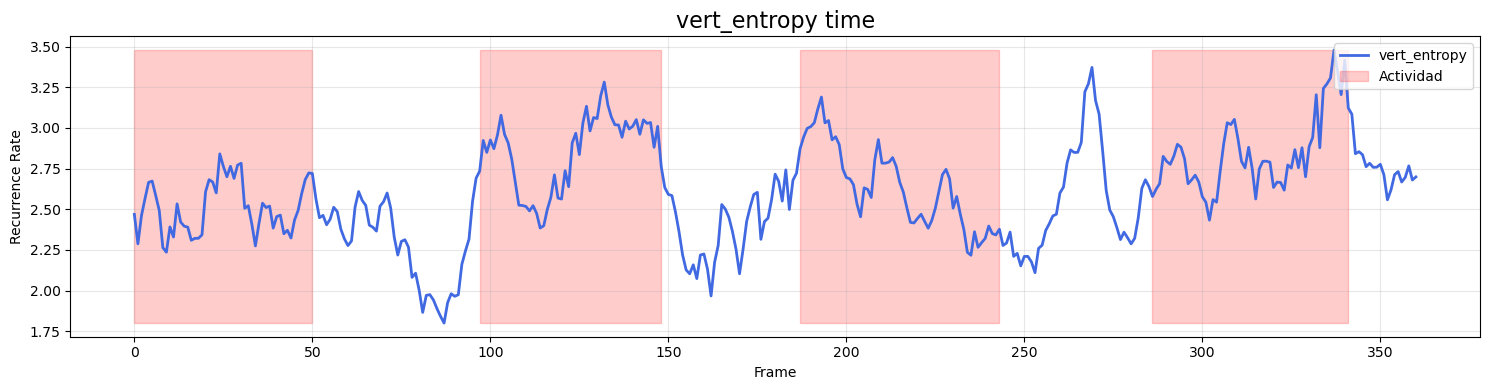

In [191]:
metric = "vert_entropy"

plt.figure(figsize=(15, 4))

# Plot de la señal continua
plt.plot(df[metric], label=metric, linewidth=2, color='royalblue')

# Crear la "sombra binaria" como una franja de fondo
binary_signal_2 = np.array(binary_signal_2)
plt.fill_between(
    range(len(binary_signal_2)),
    df[metric].min(),  # desde cero
    df[metric].max(),  # hasta el máximo de la señal
    where=binary_signal_2 > 0.5,
    color='red',
    alpha=0.2,
    step='pre',
    label="Actividad"
)

plt.title(f"{metric} time", fontsize=16)
plt.xlabel("Frame")
plt.ylabel("Recurrence Rate")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

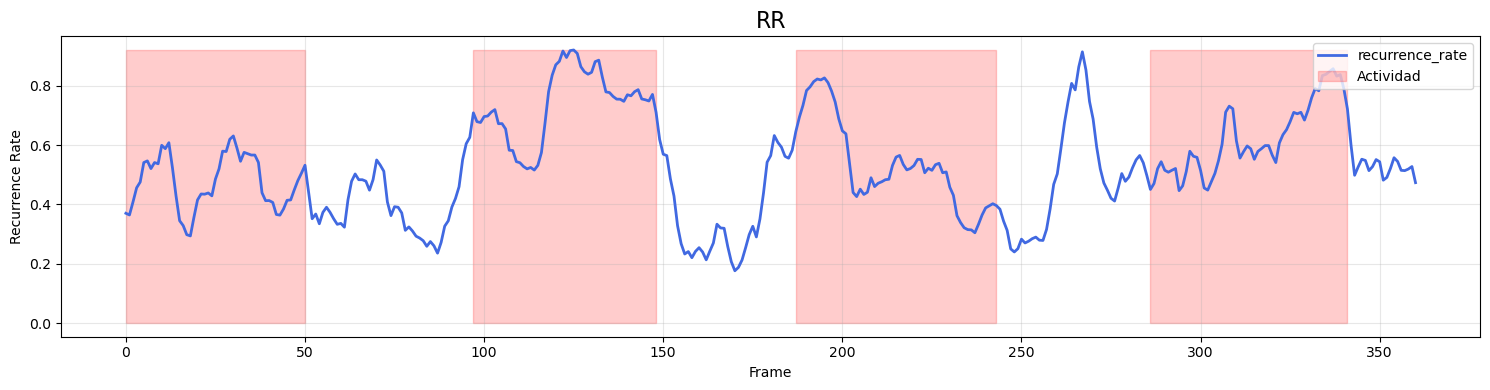

In [192]:
plt.figure(figsize=(15, 4))

# Plot de la señal continua
plt.plot(df["recurrence_rate"], label="recurrence_rate", linewidth=2, color='royalblue')

# Crear la "sombra binaria" como una franja de fondo
binary_signal_2 = np.array(binary_signal_2)
plt.fill_between(
    range(len(binary_signal_2)),
    0,  # desde cero
    df["recurrence_rate"].max(),  # hasta el máximo de la señal
    where=binary_signal_2 > 0.5,
    color='red',
    alpha=0.2,
    step='pre',
    label="Actividad"
)

plt.title("RR", fontsize=16)
plt.xlabel("Frame")
plt.ylabel("Recurrence Rate")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [193]:
#%matplotlib qt

In [194]:
thresh = data.std().mean()
segment_activity = data.values[1400: 1400 + 300, :]
rp = RecurrencePlot(
    segment_activity,
    threshold=0.09,  # 0.12 * 2 como en tu código original
    #tau=3,
    adaptive_neighborhood_size=5,
    epsilon='distance',
    metric="euclidean",
    dim=3  # Dimensión del espacio de fase
)

full_mat_act = rp.recurrence_matrix()


# Calcular métricas
RR_act = rp.recurrence_rate()       # Recurrence Rate
DET_act = rp.determinism()          # Determinism
RR_act


Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...


np.float64(0.28702222222222223)

In [195]:
thresh = data.std().mean()

segment_rest = data.values[1800: 1800 + 300, :]

rp = RecurrencePlot(
    segment_rest,
    threshold=0.09, 
    #tau=3,
    adaptive_neighborhood_size=5,
    epsilon='distance',
    metric="euclidean",
    dim=3  # Dimensión del espacio de fase
)

full_mat_rest = rp.recurrence_matrix()

# Calcular métricas
RR_rest = rp.recurrence_rate()       # Recurrence Rate
DET_rest = rp.determinism()          # Determinism
RR_rest

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...


np.float64(0.2986)

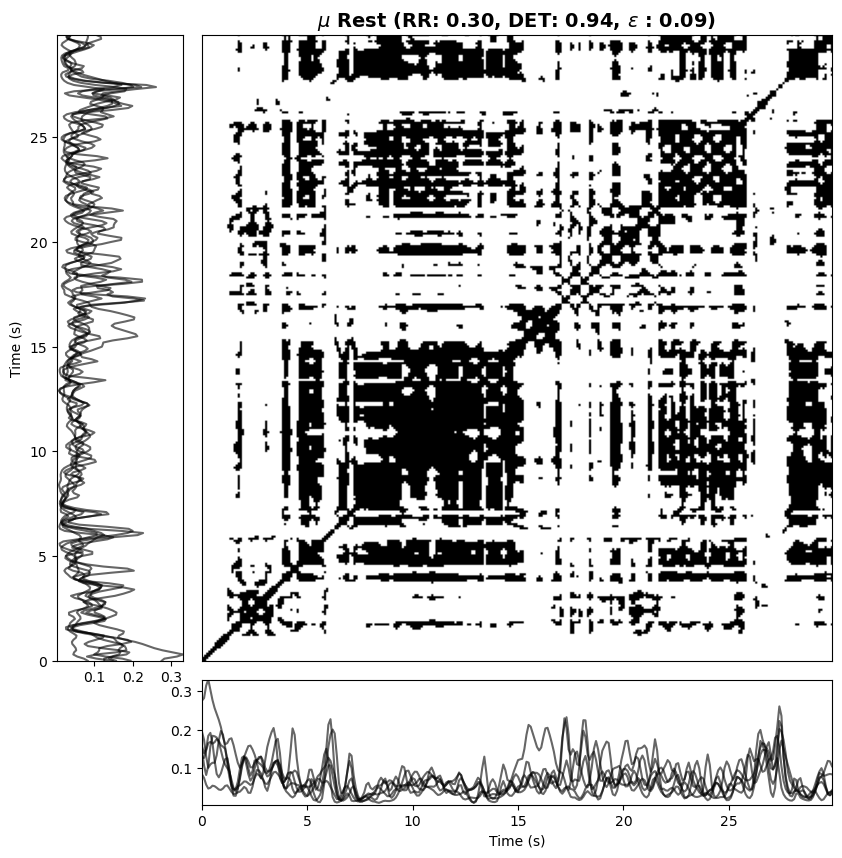

In [196]:

segment = segment_rest
full_mat = full_mat_rest
RR = RR_rest
DET = DET_rest
title = "Rest"

t = np.arange(0, len(segment)/10, 1/10)  # time vector

y_min = np.min([segment_activity, segment_rest])
y_max = np.max([segment_activity, segment_rest])

fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(2, 2, width_ratios=[0.2, 1], height_ratios=[1, 0.2], 
                      wspace=0.05, hspace=0.05)

# === Left plot (rotated version of bottom) ===
ax_left = fig.add_subplot(gs[0, 0])
for ch in range(segment.shape[1]):
    # plot each channel along y-axis
    ax_left.plot(segment[:, ch], t, color='black', alpha=0.6)

ax_left.invert_yaxis()          # First channel at top
ax_left.set_xlim(y_min, y_max)
ax_left.set_ylim(0, t[-1])
ax_left.set_ylabel("Time (s)")

# === Bottom plot ===
ax_bottom = fig.add_subplot(gs[1, 1])
for ch in range(segment.shape[1]):
    ax_bottom.plot(t, segment[:, ch], color='black', alpha=0.6)

ax_bottom.set_ylim(y_min, y_max)
ax_bottom.set_xlim(0, t[-1])
ax_bottom.set_xlabel("Time (s)")

# === Main matrix plot ===
ax_main = fig.add_subplot(gs[0, 1])
im = ax_main.imshow(full_mat, cmap='binary', origin='lower', aspect='auto')
ax_main.set_title(f"$\{band}$ {title} (RR: {RR:.2f}, DET: {DET:.2f}, $\epsilon$ : 0.09)", fontweight='bold', fontsize=14)

ax_main.set_xticks([])
ax_main.set_yticks([])

plt.show()


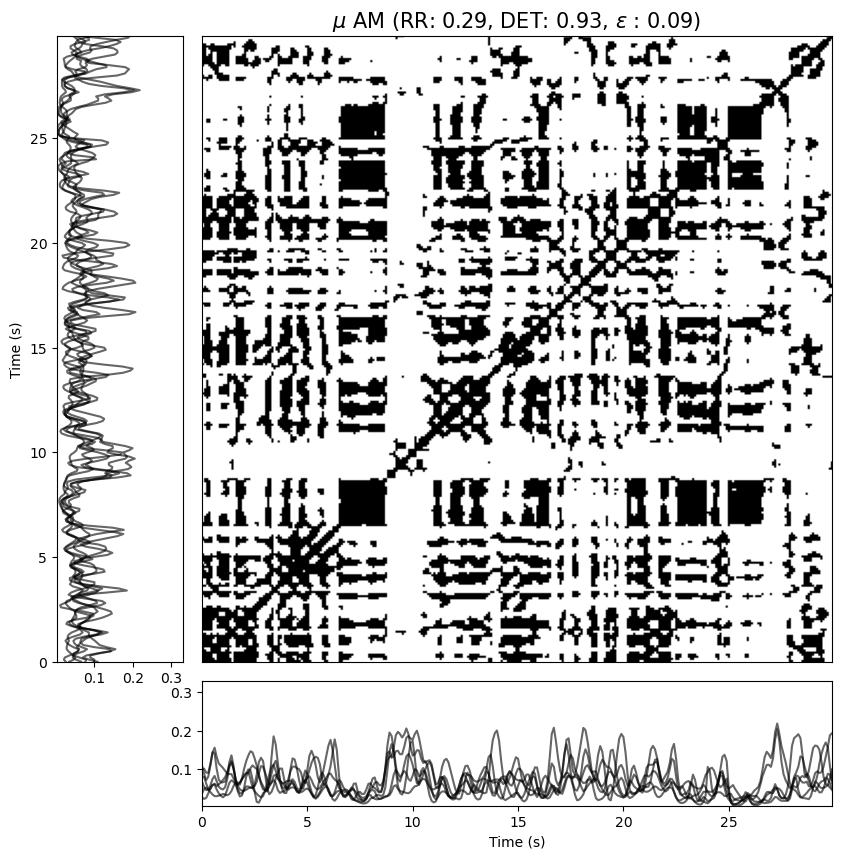

In [197]:
segment = segment_activity
full_mat = full_mat_act
RR = RR_act
DET = DET_act
title = "AM"

t = np.arange(0, len(segment)/10, 1/10)  # time vector

y_min = np.min([segment_activity, segment_rest])
y_max = np.max([segment_activity, segment_rest])

fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(2, 2, width_ratios=[0.2, 1], height_ratios=[1, 0.2], 
                      wspace=0.05, hspace=0.05)

# === Left plot (rotated version of bottom) ===
ax_left = fig.add_subplot(gs[0, 0])
for ch in range(segment.shape[1]):
    ax_left.plot(segment[:, ch], t, color='black', alpha=0.6)

ax_left.invert_yaxis()         
ax_left.set_xlim(y_min, y_max)
ax_left.set_ylim(0, t[-1])
ax_left.set_ylabel("Time (s)")

# === Bottom plot ===
ax_bottom = fig.add_subplot(gs[1, 1])
for ch in range(segment.shape[1]):
    ax_bottom.plot(t, segment[:, ch], color='black', alpha=0.6)

ax_bottom.set_ylim(y_min, y_max)
ax_bottom.set_xlim(0, t[-1])
ax_bottom.set_xlabel("Time (s)")

# === Main matrix plot ===
ax_main = fig.add_subplot(gs[0, 1])
im = ax_main.imshow(full_mat, cmap='binary', origin='lower', aspect='auto')
ax_main.set_title(f"$\{band}$ {title} (RR: {RR:.2f}, DET: {DET:.2f}, $\epsilon$ : 0.09)", fontsize=15)

ax_main.set_xticks([])
ax_main.set_yticks([])

plt.show()


In [198]:
df

,recurrence_rate,determinism,laminarity,trapping_time,diag_entropy,vert_entropy,avg_diag_length,average_vertlength,average_white_vertlength,max_diaglength,max_vertlength,max_white_vertlength,mean_recurrence_time,Bin
0,0.370000,0.939685,0.979730,6.572238,2.043034,2.468515,4.735683,6.572238,9.931034,48,21,59,9.931034,1
1,0.364375,0.924512,0.972985,6.165761,1.941104,2.287259,4.411017,6.165761,9.394919,55,21,56,9.394919,1
2,0.408750,0.957413,0.987003,7.073973,2.084974,2.461009,4.836653,7.073973,9.931759,62,22,63,9.931759,1
3,0.455937,0.968992,0.991090,8.817073,2.366019,2.566499,5.901288,8.817073,9.285333,69,29,70,9.285333,1
4,0.475313,0.979743,0.994740,11.043796,2.600478,2.665236,7.255000,11.043796,10.526646,76,36,77,10.526646,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
356,0.514687,0.965152,0.982696,7.563084,2.213253,2.667483,5.187291,7.563084,6.497908,41,38,38,6.497908,0
357,0.513750,0.963217,0.981448,7.832524,2.246288,2.695757,5.309278,7.832524,6.824561,44,40,45,6.824561,0
358,0.519062,0.965453,0.981036,8.271574,2.358422,2.766629,5.753676,8.271574,6.647948,51,47,52,6.647948,0
359,0.527500,0.961165,0.980746,7.717949,2.190319,2.679792,5.297659,7.717949,6.273859,55,48,59,6.273859,0


In [199]:
(len(df.Bin) * 10) / len(binary_signal)

1.385264773599386

In [200]:
len(binary_signal)

2606

In [201]:

df.to_csv(rf"resultados_rqa_unitario/{band}.csv")

In [202]:
%matplotlib qt

In [203]:
data

,mu_C2,mu_C1,mu_FCz,mu_Cz,mu_C3,mu_CP3
0,0.060045,0.078305,0.041697,0.022662,0.049447,0.022822
1,0.050178,0.089769,0.043771,0.021880,0.039001,0.018369
2,0.033015,0.089838,0.047580,0.020560,0.033007,0.013488
3,0.014368,0.070380,0.062818,0.025963,0.044322,0.012018
4,0.009859,0.052260,0.070042,0.043147,0.075741,0.014975
...,...,...,...,...,...,...
2601,0.121066,0.132065,0.150749,0.110596,0.237847,0.113736
2602,0.122638,0.115141,0.124615,0.096282,0.196666,0.087254
2603,0.105928,0.162913,0.135475,0.076275,0.233983,0.068095
2604,0.094265,0.210695,0.177675,0.070227,0.305534,0.070803


In [204]:
from matplotlib.animation import FuncAnimation
from matplotlib.collections import LineCollection

xx = data.mu_Cz.values      
yy = data.mu_C3.values
binary = binary_signal      

fig, ax = plt.subplots()
ax.set_xlim(np.min(xx), np.max(xx))
ax.set_ylim(np.min(yy), np.max(yy))
ax.set_xlabel("mu Cz")
ax.set_ylabel("mu C3")
ax.grid()
title = ax.set_title("")

window = 30  # tail length

# Empty LineCollection for fading tail
segments = LineCollection([], linewidths=2)
ax.add_collection(segments)

def update(frame):
    start = max(0, frame - window)
    
    x_tail = xx[start:frame]
    y_tail = yy[start:frame]
    
    if len(x_tail) > 1:
        # Create segments [(x0,y0)->(x1,y1), (x1,y1)->(x2,y2), ...]
        points = np.array([x_tail, y_tail]).T.reshape(-1, 1, 2)
        segs = np.concatenate([points[:-1], points[1:]], axis=1)

        # Fading alphas
        alphas = np.linspace(0.1, 1.0, len(segs))
        if binary[frame] > 0.5:
            colors = [(1, 0, 0, a) for a in alphas]  # red fade
        else:
            colors = [(0, 0, 1, a) for a in alphas]  # blue fade

        segments.set_segments(segs)
        segments.set_color(colors)

    
    return segments, title

ani = FuncAnimation(fig, update, frames=len(xx), interval=25, blit=True)

# === Save animation ===
#ani.save("comet_animation.mp4", writer="ffmpeg", fps=30)
# Or save as gif:
#ani.save("comet_animation.gif", writer="pillow", fps=30)

plt.show()

In [205]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from scipy.stats import gaussian_kde

# Replace with your real data
xx = data.mu_Cz.values      
yy = data.mu_C3.values
zz = data.mu_C2.values
binary = binary_signal

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot limits with padding
x_range = np.max(xx) - np.min(xx)
y_range = np.max(yy) - np.min(yy)
z_range = np.max(zz) - np.min(zz)

ax.set_xlim(np.min(xx)-0.1*x_range, np.max(xx)+0.1*x_range)
ax.set_ylim(np.min(yy)-0.1*y_range, np.max(yy)+0.1*y_range)
ax.set_zlim(np.min(zz)-0.1*z_range, np.max(zz)+0.1*z_range)

ax.set_xlabel("mu C1")
ax.set_ylabel("mu Cz")
ax.set_zlabel("mu C2")

# -----------------------------
# Function to plot KDE projection on any plane
# -----------------------------
def kde_projection(a_data, b_data, binary, zdir, offset, cmap1='Reds', cmap2='Greys'):
    
    red_idx = np.where(binary > 0.5)[0]
    blue_idx = np.where(binary <= 0.5)[0]

    a_r, b_r = a_data[red_idx], b_data[red_idx]
    a_b, b_b = a_data[blue_idx], b_data[blue_idx]

    kde_r = gaussian_kde(np.vstack([a_r, b_r]), bw_method=0.3)
    kde_b = gaussian_kde(np.vstack([a_b, b_b]), bw_method=0.3)

    agrid = np.linspace(np.min(np.concatenate([a_r, a_b])), np.max(np.concatenate([a_r, a_b])), 100)
    bgrid = np.linspace(np.min(np.concatenate([b_r, b_b])), np.max(np.concatenate([b_r, b_b])), 100)
    A, B = np.meshgrid(agrid, bgrid)

    Z_r = kde_r(np.vstack([A.ravel(), B.ravel()])).reshape(A.shape)
    Z_b = kde_b(np.vstack([A.ravel(), B.ravel()])).reshape(A.shape)

    if zdir == 'z':
        ax.contourf(A, B, Z_r, zdir="z", offset=offset, levels=4, cmap=cmap1, alpha=0.2, linestyles="dashed", zorder=1)
        ax.contourf(A, B, Z_b, zdir="z", offset=offset, levels=4, cmap=cmap2, alpha=0.2, linestyles="dashed", zorder=1)
        
    if zdir == 'x':
        ax.contourf(Z_r ,A, B, zdir="x", offset=offset, levels=4, cmap=cmap1, alpha=0.2, linestyles="dashed", zorder=1)
        ax.contourf(Z_b, A, B, zdir="x", offset=offset, levels=4, cmap=cmap2, alpha=0.2, linestyles="dashed", zorder=1)
    if zdir == 'y':
        ax.contourf(A ,Z_r, B, zdir="y", offset=offset, levels=4, cmap=cmap1, alpha=0.2, linestyles="dashed", zorder=1)
        ax.contourf(A, Z_b, B, zdir="y", offset=offset, levels=4, cmap=cmap2, alpha=0.2, linestyles="dashed", zorder=1)
        

# -----------------------------
# KDE projections on three planes
# -----------------------------
# XY plane (facing Z)
z_bottom = np.min(zz)-0.01*z_range
kde_projection(xx, yy, binary, zdir='z', offset=z_bottom)

# XZ plane (facing Y)
y_back = np.max(yy)+0.01*y_range
kde_projection(xx, zz, binary, zdir='y', offset=y_back)

# YZ plane (facing X)
x_left = np.min(xx)-0.01*x_range
kde_projection(yy, zz, binary, zdir='x', offset=x_left)

# -----------------------------
# 3D comet tail setup
# -----------------------------
window = 50
segments = Line3DCollection(np.empty((0,2,3)), linewidths=2, zorder=10)
ax.add_collection3d(segments)
head, = ax.plot([], [], [], 'o', color='black', markersize=8, zorder=10)
title = ax.set_title("")

# -----------------------------
# Animation update function
# -----------------------------
def update(frame):
    if frame >= len(xx):
        return segments, head, title

    start = max(0, frame - window)
    x_tail = xx[start:frame+1]
    y_tail = yy[start:frame+1]
    z_tail = zz[start:frame+1]

    tail_color = (1,0,0) if binary[frame]>0.5 else (0,0,1)

    if len(x_tail)>1:
        points = np.array([x_tail, y_tail, z_tail]).T.reshape(-1,1,3)
        segs = np.concatenate([points[:-1], points[1:]], axis=1)
        alphas = np.linspace(0.5,1.0,len(segs))
        colors = [(tail_color[0],tail_color[1],tail_color[2],a) for a in alphas]
        segments.set_segments(segs)
        segments.set_color(colors)

    head.set_data([xx[frame]], [yy[frame]])
    head.set_3d_properties([zz[frame]])
    head.set_color('red' if binary[frame]>0.5 else 'grey')

    return segments, head, title

# -----------------------------
# Run animation
# -----------------------------
ani = FuncAnimation(fig, update, frames=len(xx), interval=50, blit=False, repeat=False)
plt.tight_layout()
#ani.save("comet_animation_3.mp4", writer="ffmpeg", fps=30)
plt.show()
